In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
# !pip install torch==2.5.1 torchvision==0.20.1 -q
# !pip install matplotlib==3.9.4 numpy==1.26.4 scikit-learn==1.5.2 -q
!pip install torch torchvision matplotlib numpy -U -q
# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.5.1")
# _install("torchvision==0.20.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")
# _install("scikit-learn==1.5.2")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 108.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.


In [2]:
import math, copy, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# 对比学习串烧：从 InstDisc 到 CMC — 代码实战

基于对比学习（Contrastive Learning）早期四篇代表性工作：
- **InstDisc** — Instance Discrimination (Wu et al., 2018)
- **InvaSpread** — Invariant and Spreading (Ye et al., 2019)
- **CPC** — Contrastive Predictive Coding (van den Oord et al., 2018)
- **CMC** — Contrastive Multiview Coding (Tian et al., 2020)

用 **CIFAR-10 子集上的自监督特征学习 + 线性评估** 演示对比学习核心机制。

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — InstDisc (Memory Bank) | 实现 B — InvaSpread (端到端 Batch 内对比) |
|---|---|---|
| 核心思路 | Memory Bank 存储全数据集特征，NCE 采样负样本 | 同一 Batch 内构造正负样本，端到端训练 |
| 负样本来源 | Memory Bank 随机采样 | 同一 Batch 中其他样本 |
| 代码量 | ~150 行 | ~100 行 |
| 特点 | 解耦字典大小与 batch size | 简单直接，无需额外存储 |

## 1. 数据准备

对比学习的核心是**数据增强**：对同一图像做两次不同的随机增强，得到的两个视图构成正样本对（positive pair），不同图像的视图为负样本。

增强策略选择依据（来自 SimCLR 的发现）：
- **随机裁剪 + 翻转**：引入空间变化
- **颜色抖动（Color Jitter）**：迫使模型不依赖颜色捷径
- **灰度化**：进一步消除颜色信息

In [3]:
# ── 对比学习数据增强 ──
contrastive_augmentation = T.Compose([
    T.RandomResizedCrop(32, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])


class ContrastivePairDataset(Dataset):
    """对同一图像做两次独立增强，返回 (view1, view2)."""
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]
        return self.transform(img), self.transform(img)


# 下载 CIFAR-10
full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=None)

# 预训练: 5000 张（无标签）
pretrain_base = Subset(full_train, list(range(5000)))
pretrain_dataset = ContrastivePairDataset(pretrain_base, contrastive_augmentation)

# 线性评估: 5000 张（有标签）
eval_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=eval_transform)
eval_dataset = Subset(eval_full, list(range(5000)))

# 测试集: 1000 张
test_full = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=eval_transform)
test_dataset = Subset(test_full, list(range(1000)))

print(f'预训练集: {len(pretrain_dataset)}')
print(f'线性评估集: {len(eval_dataset)}')
print(f'测试集: {len(test_dataset)}')

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


预训练集: 5000
线性评估集: 5000
测试集: 1000


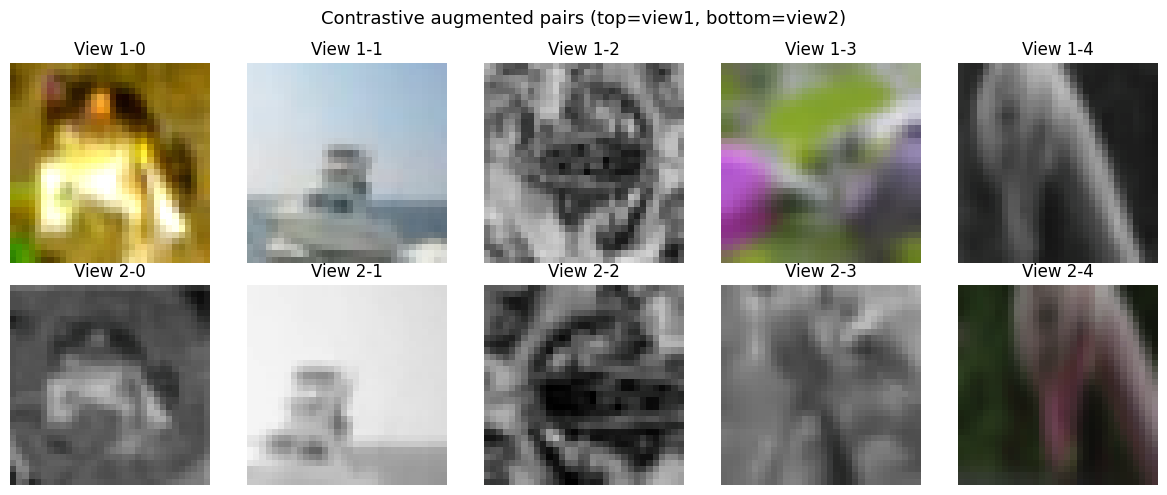

In [4]:
# ── 可视化增强对 ──
def denormalize(tensor, mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)):
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Contrastive augmented pairs (top=view1, bottom=view2)', fontsize=13)
for i in range(5):
    v1, v2 = pretrain_dataset[i * 100]
    axes[0, i].imshow(denormalize(v1).permute(1, 2, 0).numpy())
    axes[0, i].set_title(f'View 1-{i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(v2).permute(1, 2, 0).numpy())
    axes[1, i].set_title(f'View 2-{i}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 2. 共享组件

超参数集中管理，两种实现共用同一套配置。

In [5]:
# ── 超参数（两种实现共用，集中管理） ──
FEATURE_DIM   = 128    # 特征维度
BANK_SIZE     = 5000   # Memory Bank 大小（= 预训练集大小）
TEMPERATURE   = 0.07   # 温度参数 τ
NCE_K         = 4096   # NCE 负样本采样数
MOMENTUM_BANK = 0.5    # Memory Bank 动量更新系数
LR            = 1e-3
NUM_EPOCHS    = 20     # CPU 友好
BATCH_SIZE    = 128
EVAL_EPOCHS   = 30     # 线性评估轮数

pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, drop_last=True, num_workers=0)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

In [6]:
class Encoder(nn.Module):
    """轻量 CNN 编码器 + 投影头.
    (B, 3, 32, 32) → Conv layers → GAP → projection → L2 norm → (B, feature_dim)
    """
    def __init__(self, feature_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),   # (B, 32, 16, 16)
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # (B, 64, 8, 8)
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # (B, 128, 4, 4)
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),# (B, 256, 2, 2)
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                     # (B, 256, 1, 1)
        )
        self.projection = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )

    def forward(self, x):
        h = self.backbone(x).view(x.size(0), -1)  # (B, 256)
        return F.normalize(self.projection(h), dim=1)  # (B, feature_dim)

_test_enc = Encoder(FEATURE_DIM)
print(f'Encoder output: {_test_enc(torch.randn(4, 3, 32, 32)).shape}')

Encoder output: torch.Size([4, 128])


In [7]:
def linear_eval(encoder, train_loader, test_loader, feature_dim,
                num_classes=10, num_epochs=30, device='cpu'):
    """冻结编码器，训练线性分类头评估特征质量."""
    encoder.eval()
    encoder.to(device)
    classifier = nn.Linear(feature_dim, num_classes).to(device)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    def extract(loader):
        feats, labels = [], []
        with torch.no_grad():
            for x, y in loader:
                feats.append(encoder(x.to(device)).cpu())
                labels.append(y)
        return torch.cat(feats), torch.cat(labels)

    train_feats, train_labels = extract(train_loader)
    test_feats, test_labels = extract(test_loader)
    tr = DataLoader(torch.utils.data.TensorDataset(train_feats, train_labels),
                    batch_size=256, shuffle=True)
    te = DataLoader(torch.utils.data.TensorDataset(test_feats, test_labels),
                    batch_size=256)

    for epoch in range(num_epochs):
        classifier.train()
        for f, l in tr:
            f, l = f.to(device), l.to(device)
            loss = criterion(classifier(f), l)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

    classifier.eval()
    with torch.no_grad():
        correct = sum((classifier(f.to(device)).argmax(1) == l.to(device)).sum().item()
                      for f, l in te)
    total = len(test_feats)
    acc = correct / total
    print(f'  Linear eval accuracy: {acc:.4f} ({correct}/{total})')
    return acc

## 3. 实现 A — InstDisc (Memory Bank)

**InstDisc**（Instance Discrimination, Wu et al. 2018）将每张图片视为独立类别，是对比学习的开山之作。

### 核心机制
1. **Memory Bank**：存储整个数据集中每张图片的特征向量，无需重新计算
2. **非参数 Softmax**：不使用可学习的分类权重，直接用 Memory Bank 中的特征计算相似度
3. **NCE 采样**：从 Memory Bank 中随机采样负样本，避免对全数据集做 softmax

### 损失函数 — 噪声对比估计 (NCE)

$$\mathcal{L} = -\log \frac{\exp(v \cdot m_y / \tau)}{\exp(v \cdot m_y / \tau) + \sum_{j=1}^{K} \exp(v \cdot m_j / \tau)}$$

- $v$: query 编码器输出的特征（已 L2 归一化）
- $m_y$: Memory Bank 中对应正样本的特征
- $m_j$: 从 Memory Bank 中随机采样的 $K$ 个负样本
- $\tau = 0.07$: 温度参数

### Memory Bank 更新

每次前向传播后，用动量方式更新 Memory Bank 中对应位置的特征：

$$m_y \leftarrow \lambda \cdot m_y + (1 - \lambda) \cdot v$$

这保证 Memory Bank 中的特征逐步跟踪编码器的变化。

In [8]:
class MemoryBank:
    """Memory Bank: 存储整个数据集的特征向量.

    - 初始化为随机单位向量
    - 每次前向传播后动量更新对应位置
    - 提供随机负样本采样
    """
    def __init__(self, n_samples, feature_dim, device='cpu'):
        # (n_samples, feature_dim) — 随机初始化并 L2 归一化
        self.bank = F.normalize(
            torch.randn(n_samples, feature_dim), dim=1
        ).to(device)
        self.device = device

    def update(self, indices, features, momentum=0.5):
        """动量更新: m_y ← λ·m_y + (1-λ)·v.
        indices: (B,) — 样本在数据集中的索引
        features: (B, d) — 编码器输出的新特征
        """
        with torch.no_grad():
            features = F.normalize(features, dim=1)
            self.bank[indices] = (momentum * self.bank[indices] +
                                  (1 - momentum) * features)
            # 重新归一化
            self.bank[indices] = F.normalize(self.bank[indices], dim=1)

    def sample_negatives(self, n_neg):
        """从 Memory Bank 中随机采样 n_neg 个负样本.
        Returns: (n_neg, d)
        """
        indices = torch.randint(0, self.bank.size(0), (n_neg,))
        return self.bank[indices]  # (n_neg, d)

    def get(self, indices):
        """获取指定索引的特征. Returns: (B, d)"""
        return self.bank[indices]

print(f'MemoryBank initialized: {BANK_SIZE} samples × {FEATURE_DIM} dim')

MemoryBank initialized: 5000 samples × 128 dim


In [9]:
class InstDisc(nn.Module):
    """InstDisc: Instance Discrimination with Memory Bank.

    数据流:
    x → Encoder → v (B, d) → NCE loss with Memory Bank → update bank
    """
    def __init__(self, feature_dim=128, bank_size=5000, nce_k=4096,
                 temperature=0.07, momentum_bank=0.5):
        super().__init__()
        self.encoder = Encoder(feature_dim)
        self.memory_bank = MemoryBank(bank_size, feature_dim)
        self.nce_k = nce_k
        self.T = temperature
        self.m = momentum_bank

    def forward(self, x1, indices):
        """
        x1: (B, 3, 32, 32) — 增强视图
        indices: (B,) — 样本在数据集中的索引
        """
        # query 编码
        v = self.encoder(x1)  # (B, d)

        # 正样本: Memory Bank 中对应索引的特征
        pos = self.memory_bank.get(indices).to(v.device)  # (B, d)

        # 负样本: 从 Memory Bank 随机采样
        neg = self.memory_bank.sample_negatives(self.nce_k).to(v.device)  # (K, d)

        # 正样本相似度: (B, 1)
        l_pos = torch.einsum('bd,bd->b', v, pos).unsqueeze(1)  # (B, 1)

        # 负样本相似度: (B, K)
        l_neg = v @ neg.T  # (B, d) × (d, K) → (B, K)

        # NCE logits: (B, 1+K)
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T

        # 标签: 正样本在 index=0
        labels = torch.zeros(v.size(0), dtype=torch.long, device=v.device)

        loss = F.cross_entropy(logits, labels)

        # 更新 Memory Bank
        self.memory_bank.update(indices, v.detach(), self.m)

        return loss

model_a = InstDisc(FEATURE_DIM, BANK_SIZE, NCE_K, TEMPERATURE, MOMENTUM_BANK)
print(f'InstDisc params: {sum(p.numel() for p in model_a.parameters()):,}')

InstDisc params: 488,064


In [10]:
# InstDisc 需要返回样本索引，用于 Memory Bank 更新
class IndexedPairDataset(Dataset):
    """返回 (view1, view2, index)."""
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]
        return self.transform(img), self.transform(img), idx

pretrain_indexed = IndexedPairDataset(pretrain_base, contrastive_augmentation)
pretrain_loader_idx = DataLoader(pretrain_indexed, batch_size=BATCH_SIZE,
                                 shuffle=True, drop_last=True, num_workers=0)

=== 实现 A: InstDisc (Memory Bank) — 预训练 ===
  Epoch [5/20]  Loss: 7.9198
  Epoch [10/20]  Loss: 7.0588
  Epoch [15/20]  Loss: 6.7773
  Epoch [20/20]  Loss: 6.3739


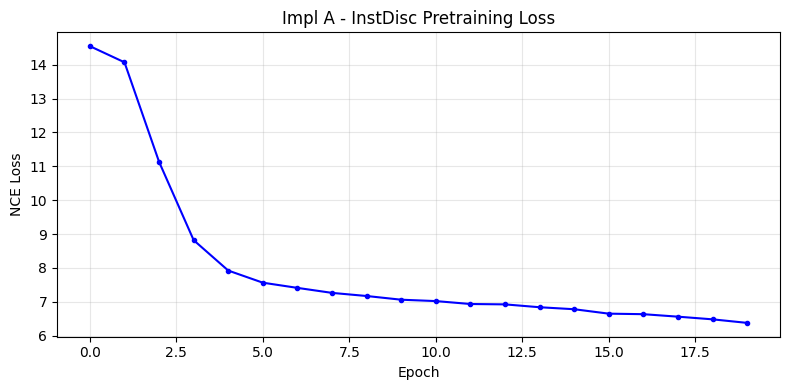

In [11]:
# ── 实现 A 训练 ──
print('=== 实现 A: InstDisc (Memory Bank) — 预训练 ===')
model_a.to(device)
model_a.memory_bank.bank = model_a.memory_bank.bank.to(device)
optimizer_a = torch.optim.Adam(model_a.encoder.parameters(), lr=LR)

losses_a = []
for epoch in range(NUM_EPOCHS):
    model_a.train()
    epoch_loss = 0.0
    for x1, _, indices in pretrain_loader_idx:
        x1 = x1.to(device)
        loss = model_a(x1, indices)
        optimizer_a.zero_grad()
        loss.backward()
        optimizer_a.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(pretrain_loader_idx)
    losses_a.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {avg:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses_a, 'b-o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('NCE Loss')
plt.title('Impl A - InstDisc Pretraining Loss'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
print('=== 实现 A: 线性评估 ===')
acc_a = linear_eval(model_a.encoder, eval_loader, test_loader,
                    FEATURE_DIM, num_epochs=EVAL_EPOCHS, device=device)

=== 实现 A: 线性评估 ===
  Linear eval accuracy: 0.3440 (344/1000)


## 4. 实现 B — InvaSpread (Batch 内对比)

**InvaSpread**（Ye et al., 2019）直接在一个 Batch 内构造正负样本，不需要 Memory Bank。

### 核心思路
- Batch 中每张图片 $x_i$ 与其增强版本 $\hat{x}_i$ 构成**正样本对**
- 同一 Batch 中其他图片及其增强均为**负样本**
- 这种设计后来被 SimCLR 进一步发展

### NT-Xent 损失 (Normalized Temperature-scaled Cross Entropy)

对于 Batch 中第 $i$ 个正样本对 $(z_i, z_j)$：

$$\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

其中 $\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$ 是余弦相似度，$N$ 是 Batch 大小。

### InvaSpread vs InstDisc

| 特性 | InstDisc | InvaSpread |
|------|---------|------------|
| 负样本来源 | Memory Bank | 同一 Batch |
| 额外存储 | Memory Bank (N × d) | 无 |
| 特征一致性 | 可能不一致（旧特征） | 天然一致（同一编码器） |
| 负样本数量 | 可调（NCE_K） | 受限于 Batch 大小 |

In [13]:
class InvaSpread(nn.Module):
    """InvaSpread: Batch 内对比学习（类似 SimCLR 简化版）.

    数据流:
    x1, x2 → shared Encoder → z1, z2 (B, d) → NT-Xent loss
    """
    def __init__(self, feature_dim=128, temperature=0.07):
        super().__init__()
        self.encoder = Encoder(feature_dim)
        self.T = temperature

    def forward(self, x1, x2):
        """
        x1: (B, 3, 32, 32) — 增强视图 1
        x2: (B, 3, 32, 32) — 增强视图 2
        """
        z1 = self.encoder(x1)  # (B, d)
        z2 = self.encoder(x2)  # (B, d)
        B = z1.size(0)

        # 拼接所有特征: (2B, d)
        z = torch.cat([z1, z2], dim=0)

        # 计算全部两两相似度: (2B, 2B)
        sim_matrix = z @ z.T / self.T  # (2B, 2B)

        # 构造正样本 mask: 对角线位移 B 的位置
        # z1[i] 的正样本是 z2[i]（位于 index i+B），反之亦然
        pos_mask = torch.zeros(2 * B, 2 * B, dtype=torch.bool, device=z.device)
        pos_mask[range(B), range(B, 2*B)] = True   # z1→z2
        pos_mask[range(B, 2*B), range(B)] = True   # z2→z1

        # 排除自身 (对角线)
        self_mask = ~torch.eye(2 * B, dtype=torch.bool, device=z.device)

        # 正样本 logits: (2B,)
        pos_logits = sim_matrix[pos_mask]  # (2B,)

        # 分母: 所有非自身样本的 exp sum
        neg_logits = sim_matrix.masked_fill(~self_mask, -1e9)  # 屏蔽自身
        log_sum_exp = torch.logsumexp(neg_logits, dim=1)  # (2B,)

        # NT-Xent loss: -log(exp(pos) / sum(exp(all)))
        loss = (-pos_logits + log_sum_exp).mean()
        return loss

model_b = InvaSpread(FEATURE_DIM, TEMPERATURE)
print(f'InvaSpread params: {sum(p.numel() for p in model_b.parameters()):,}')

InvaSpread params: 488,064


=== 实现 B: InvaSpread (Batch 内对比) — 预训练 ===
  Epoch [5/20]  Loss: 3.4077
  Epoch [10/20]  Loss: 2.9200
  Epoch [15/20]  Loss: 2.5352
  Epoch [20/20]  Loss: 2.2755


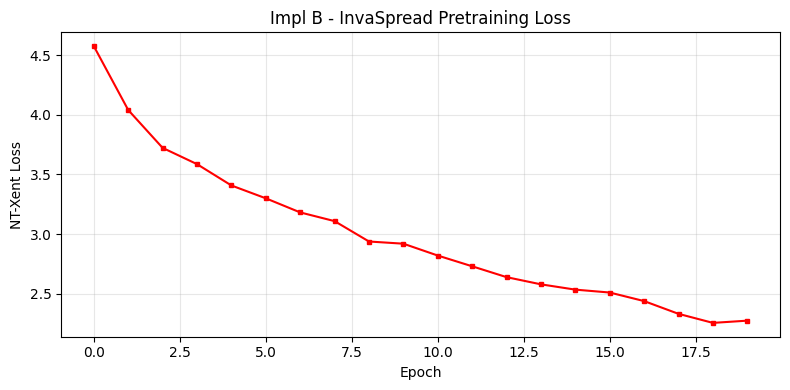

In [14]:
print('=== 实现 B: InvaSpread (Batch 内对比) — 预训练 ===')
model_b.to(device)
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=LR)

losses_b = []
for epoch in range(NUM_EPOCHS):
    model_b.train()
    epoch_loss = 0.0
    for x1, x2 in pretrain_loader:
        x1, x2 = x1.to(device), x2.to(device)
        loss = model_b(x1, x2)
        optimizer_b.zero_grad()
        loss.backward()
        optimizer_b.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(pretrain_loader)
    losses_b.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {avg:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses_b, 'r-s', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.title('Impl B - InvaSpread Pretraining Loss'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
print('=== 实现 B: 线性评估 ===')
acc_b = linear_eval(model_b.encoder, eval_loader, test_loader,
                    FEATURE_DIM, num_epochs=EVAL_EPOCHS, device=device)

=== 实现 B: 线性评估 ===
  Linear eval accuracy: 0.4550 (455/1000)


## 5. 结果对比

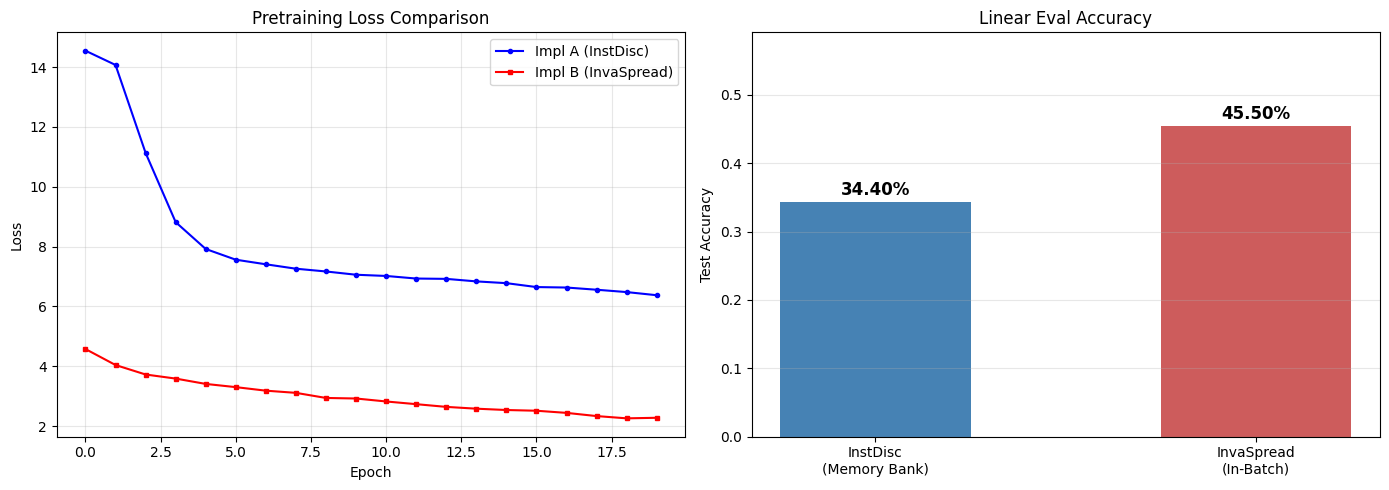


实现 A (InstDisc)   准确率: 0.3440
实现 B (InvaSpread)  准确率: 0.4550


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_a, 'b-o', markersize=3, label='Impl A (InstDisc)')
axes[0].plot(losses_b, 'r-s', markersize=3, label='Impl B (InvaSpread)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Pretraining Loss Comparison'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(['InstDisc\n(Memory Bank)', 'InvaSpread\n(In-Batch)'],
                   [acc_a, acc_b], color=['steelblue', 'indianred'], width=0.5)
axes[1].set_ylabel('Test Accuracy'); axes[1].set_title('Linear Eval Accuracy')
axes[1].set_ylim(0, max(acc_a, acc_b) * 1.3)
for bar, acc in zip(bars, [acc_a, acc_b]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\n{"="*50}')
print(f'实现 A (InstDisc)   准确率: {acc_a:.4f}')
print(f'实现 B (InvaSpread)  准确率: {acc_b:.4f}')
print(f'{"="*50}')

## 附录 A：面试拓展

### 高频面试题

**Q1: InstDisc 的 Memory Bank 存在什么问题？MoCo 如何解决？**

- Memory Bank 中的特征由不同时间步的编码器生成，随着训练进行，早期存储的特征与当前编码器输出不一致
- MoCo 的解决方案：用**动量编码器**替代 Memory Bank。动量编码器以 $\theta_k \leftarrow 0.999 \cdot \theta_k + 0.001 \cdot \theta_q$ 缓慢更新，确保队列中所有 key 由"几乎相同"的编码器生成

**Q2: InvaSpread 和 SimCLR 的关系是什么？**

- InvaSpread 是 SimCLR 的前身，核心思想一致：在 Batch 内构造正负样本
- SimCLR 的主要改进：(1) 更强的数据增强组合；(2) 加入非线性投影头（MLP）显著提升效果；(3) 使用更大的 Batch Size（4096+）
- InvaSpread 没有 projection head，SimCLR 证明了 projection head 的重要性

**Q3: CPC (Contrastive Predictive Coding) 的代理任务与 InstDisc 有何不同？**

- InstDisc 的代理任务是**实例判别**：判断两个视图是否来自同一图像
- CPC 的代理任务是**序列预测**：利用上下文信息预测未来时步的潜在表示
- CPC 更通用：可处理音频、视频、文本等序列数据
- CPC 的正样本是"真实的未来编码"，负样本是"随机时步的编码"

**Q4: CMC (Contrastive Multiview Coding) 的核心思想是什么？与 CLIP 有什么关系？**

- CMC 的核心：最大化同一样本在不同**视图/模态**下嵌入的一致性
- 正样本 = 同一样本的不同视图（如 RGB、深度图、语义分割）
- CMC 直接启发了 CLIP：图像-文本对替代多视图，匹配的图文对为正例
- 局限性：多视图方法需要多个编码器，训练代价高

**Q5: 对比学习的四个发展阶段是什么？**

| 阶段 | 代表工作 | 核心特点 |
|------|---------|----------|
| 百花齐放 | InstDisc, InvaSpread, CPC, CMC | 探索不同代理任务和正负样本构造 |
| CV 双雄 | MoCo, SimCLR | 大规模预训练，系统性实验 |
| 不用负样本 | BYOL, SimSiam | 证明负样本非必需 |
| Transformer 时代 | MoCo v3, DINO | 与 ViT 结合，自蒸馏 |

**Q6: 温度参数 τ 在对比学习中的作用？**

- τ 小 → softmax 分布尖锐 → 模型更关注最难区分的负样本（hard negatives）→ 特征更精细但训练不稳定
- τ 大 → 分布平滑 → 平等对待所有负样本 → 更鲁棒但特征粗糙
- InstDisc/MoCo: τ=0.07；SimCLR: τ=0.5（负样本少，需更平滑梯度）

**Q7: 为什么对比学习需要强数据增强？**

- 弱增强 → 正样本对之间差异太小 → 模型学到低级特征（如颜色、纹理）即可区分正负样本
- 强增强（裁剪+颜色抖动+灰度化）→ 迫使模型捕获**语义特征**才能正确匹配
- SimCLR 的实验表明：单一增强（仅裁剪或仅颜色变换）效果远不如组合增强

### 延伸阅读与对比

| 对比维度 | InstDisc | InvaSpread / SimCLR | MoCo | BYOL |
|---------|---------|-------------------|------|------|
| 负样本来源 | Memory Bank | Batch 内 | 动态队列 | 不需要 |
| 编码器 | 单编码器 | 单编码器（共享） | 双编码器（动量） | 双编码器（动量） |
| 硬件需求 | 低 | 高（需大 Batch） | 低 | 中 |
| 特征一致性 | 低 | 高 | 高 | 高 |
| 历史地位 | 开山之作 | 简洁范式 | 里程碑 | 新范式 |

### 进阶探索方向

- **DINO / DINOv2**：自蒸馏 + ViT，无需负样本和队列，学到的特征可直接做语义分割
- **MAE**：从对比学习转向掩码图像建模，更高效的预训练方式
- **多模态对比学习（CLIP）**：视觉-语言对比学习，实现零样本迁移
- **对比学习的理论分析**：InfoNCE 与互信息的关系、对齐性（alignment）与均匀性（uniformity）

## 附录 B：CPC 与 CMC 核心代码片段

以下提供 CPC 和 CMC 的核心组件实现，作为对本 Notebook 两种完整实现的补充。

In [18]:
# ── CPC: Contrastive Predictive Coding 核心组件 ──
# CPC 将图像切分为 patch 序列，用 GRU 编码上下文，预测未来 patch 的表示

class CPCPatchEncoder(nn.Module):
    """将图像切分为 patch 并编码.
    (B, 3, 32, 32) → 切分为 4×4 个 8×8 patch → 每个 patch 编码为 (B, 16, d)
    """
    def __init__(self, patch_size=8, feature_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, feature_dim),
        )

    def forward(self, x):
        B, C, H, W = x.shape  # (B, 3, 32, 32)
        p = self.patch_size
        n_h, n_w = H // p, W // p  # 4, 4
        # 切分为 patch: (B, n_h*n_w, C, p, p)
        patches = x.unfold(2, p, p).unfold(3, p, p)  # (B, C, n_h, n_w, p, p)
        patches = patches.contiguous().permute(0, 2, 3, 1, 4, 5)  # (B, n_h, n_w, C, p, p)
        patches = patches.reshape(B * n_h * n_w, C, p, p)  # (B*16, 3, 8, 8)
        z = self.encoder(patches)  # (B*16, d)
        return z.view(B, n_h * n_w, -1)  # (B, 16, d)


class CPCModel(nn.Module):
    """CPC: 用 GRU 编码上下文，预测未来 patch 的表示.

    数据流:
    x → patches → patch_encoder → z_t (B, T, d)
    z_1..z_t → GRU → c_t (context)
    c_t → W_k → 预测 z_{t+k}
    """
    def __init__(self, feature_dim=64, context_dim=128, n_predict=3):
        super().__init__()
        self.patch_encoder = CPCPatchEncoder(feature_dim=feature_dim)
        self.gru = nn.GRU(feature_dim, context_dim, batch_first=True)
        # 每个预测步一个线性层
        self.predictors = nn.ModuleList([
            nn.Linear(context_dim, feature_dim) for _ in range(n_predict)
        ])
        self.n_predict = n_predict

    def forward(self, x):
        z_all = self.patch_encoder(x)  # (B, 16, d)
        B, T, d = z_all.shape
        t_split = T - self.n_predict  # 上下文截止位置

        z_context = z_all[:, :t_split, :]  # (B, t_split, d)
        _, h = self.gru(z_context)  # h: (1, B, context_dim)
        c_t = h.squeeze(0)  # (B, context_dim)

        loss = 0.0
        for k in range(self.n_predict):
            z_future = z_all[:, t_split + k, :]  # (B, d) — 真实未来 patch
            z_pred = self.predictors[k](c_t)  # (B, d) — 预测的未来 patch
            # InfoNCE: 正样本 = 对角线，负样本 = 非对角线
            logits = z_pred @ z_future.T / 0.07  # (B, B)
            labels = torch.arange(B, device=x.device)
            loss += F.cross_entropy(logits, labels)

        return loss / self.n_predict

# 验证 CPC 模型
_cpc = CPCModel()
_cpc_loss = _cpc(torch.randn(8, 3, 32, 32))
print(f'CPC loss (random): {_cpc_loss.item():.4f}')
print(f'CPC params: {sum(p.numel() for p in _cpc.parameters()):,}')

CPC loss (random): 2.0803
CPC params: 122,816


In [19]:
# ── CMC: Contrastive Multiview Coding 核心组件 ──
# CMC 使用同一图像的不同视图（如 L 通道 和 ab 通道）进行对比学习

class CMCModel(nn.Module):
    """CMC: 双视图对比学习 (L 通道 vs ab 通道).

    数据流:
    RGB → Lab 色彩空间 → L通道 / ab通道
    L → encoder_L → z_L (B, d)
    ab → encoder_ab → z_ab (B, d)
    对比损失: 同一图像的 z_L 和 z_ab 为正样本
    """
    def __init__(self, feature_dim=128, temperature=0.07):
        super().__init__()
        # L 通道编码器 (1 channel input)
        self.encoder_l = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, feature_dim),
        )
        # ab 通道编码器 (2 channel input)
        self.encoder_ab = nn.Sequential(
            nn.Conv2d(2, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, feature_dim),
        )
        self.T = temperature

    def forward(self, img_l, img_ab):
        """
        img_l:  (B, 1, H, W) — L 通道
        img_ab: (B, 2, H, W) — ab 通道
        """
        z_l = F.normalize(self.encoder_l(img_l), dim=1)    # (B, d)
        z_ab = F.normalize(self.encoder_ab(img_ab), dim=1)  # (B, d)

        # 对称 InfoNCE
        logits_l2ab = z_l @ z_ab.T / self.T  # (B, B)
        logits_ab2l = z_ab @ z_l.T / self.T  # (B, B)
        labels = torch.arange(z_l.size(0), device=z_l.device)

        loss = (F.cross_entropy(logits_l2ab, labels) +
                F.cross_entropy(logits_ab2l, labels)) / 2
        return loss

# 验证 CMC 模型
_cmc = CMCModel()
_cmc_loss = _cmc(torch.randn(8, 1, 32, 32), torch.randn(8, 2, 32, 32))
print(f'CMC loss (random): {_cmc_loss.item():.4f}')
print(f'CMC params: {sum(p.numel() for p in _cmc.parameters()):,}')

CMC loss (random): 2.1311
CMC params: 54,944


## 附录 C：四种方法核心机制对比

| 方法 | 代理任务 | 正样本 | 负样本来源 | 关键创新 |
|------|---------|--------|-----------|----------|
| **InstDisc** | 实例判别 | Memory Bank 中对应特征 | Memory Bank 随机采样 | Memory Bank + NCE |
| **InvaSpread** | Batch 内对比 | 同一图像的增强视图 | Batch 内其他样本 | 端到端，无需额外存储 |
| **CPC** | 序列预测 | 真实的未来 patch 编码 | Batch 内其他样本的未来编码 | GRU 上下文 + 多步预测 |
| **CMC** | 多视图对比 | 同一图像的不同模态 | Batch 内其他样本 | 多编码器 + 跨模态对齐 |

In [20]:
# ── 四种方法的损失函数统一视角 ──
# 所有对比学习方法的损失函数都可以写成 InfoNCE 的变体

def info_nce_loss(query, positive, negatives, temperature=0.07):
    """InfoNCE 统一损失函数.
    query:     (B, d) — 查询特征
    positive:  (B, d) — 正样本特征
    negatives: (B, K, d) 或 (K, d) — 负样本特征
    """
    # 正样本相似度: (B,)
    pos_sim = torch.einsum('bd,bd->b', query, positive) / temperature

    if negatives.dim() == 2:
        # 所有样本共享负样本: (B, K)
        neg_sim = query @ negatives.T / temperature
    else:
        # 每个样本有不同的负样本: (B, K)
        neg_sim = torch.einsum('bd,bkd->bk', query, negatives) / temperature

    # (B, 1+K)
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
    labels = torch.zeros(query.size(0), dtype=torch.long, device=query.device)
    return F.cross_entropy(logits, labels)

# 验证
q = F.normalize(torch.randn(16, 128), dim=1)
p = F.normalize(torch.randn(16, 128), dim=1)
n = F.normalize(torch.randn(256, 128), dim=1)
print(f'InfoNCE loss (random): {info_nce_loss(q, p, n):.4f}')
print('  → 理论最优值 (当 K=256): {:.4f}'.format(math.log(257)))

InfoNCE loss (random): 6.4277
  → 理论最优值 (当 K=256): 5.5491


## 附录 D：关键概念图解

### 对比学习的本质

对比学习可以从两个角度理解：

1. **互信息最大化**：最大化正样本对之间的互信息 $I(v_1; v_2)$
   - InfoNCE 损失是互信息的下界估计
   - $\mathcal{L}_{\text{InfoNCE}} \geq \log(K) - I(v_1; v_2)$

2. **对齐性与均匀性**（Wang & Isola, 2020）：
   - **对齐性 (Alignment)**：正样本对的特征应该尽可能接近
   - **均匀性 (Uniformity)**：所有特征应均匀分布在超球面上
   - 好的对比学习方法同时优化这两个目标

In [21]:
# ── 对齐性 & 均匀性度量 ──
def alignment(z1, z2):
    """对齐性: 正样本对之间的平均 L2 距离.
    值越小 → 正样本对越接近 → 越好
    """
    return (z1 - z2).norm(dim=1).pow(2).mean().item()

def uniformity(z, t=2):
    """均匀性: 所有特征对之间的高斯势能.
    值越小 → 分布越均匀 → 越好
    """
    pdist = torch.cdist(z, z, p=2).pow(2)  # (N, N)
    return pdist.mul(-t).exp().mean().log().item()

# 对两个模型计算指标
# 提取正样本对特征
model_a.encoder.eval(); model_b.encoder.eval()
z1_list_a, z2_list_a = [], []
z1_list_b, z2_list_b = [], []
with torch.no_grad():
    for i, (v1, v2) in enumerate(pretrain_loader):
        if i >= 3: break  # 取部分样本
        z1_list_a.append(model_a.encoder(v1.to(device)).cpu())
        z2_list_a.append(model_a.encoder(v2.to(device)).cpu())
        z1_list_b.append(model_b.encoder(v1.to(device)).cpu())
        z2_list_b.append(model_b.encoder(v2.to(device)).cpu())

z1_a, z2_a = torch.cat(z1_list_a), torch.cat(z2_list_a)
z1_b, z2_b = torch.cat(z1_list_b), torch.cat(z2_list_b)

print('对齐性 & 均匀性指标（越小越好）:')
print(f'  InstDisc   — Alignment: {alignment(z1_a, z2_a):.4f}, '
      f'Uniformity: {uniformity(z1_a):.4f}')
print(f'  InvaSpread — Alignment: {alignment(z1_b, z2_b):.4f}, '
      f'Uniformity: {uniformity(z1_b):.4f}')

对齐性 & 均匀性指标（越小越好）:
  InstDisc   — Alignment: 0.3408, Uniformity: -1.7073
  InvaSpread — Alignment: 0.6305, Uniformity: -3.0178


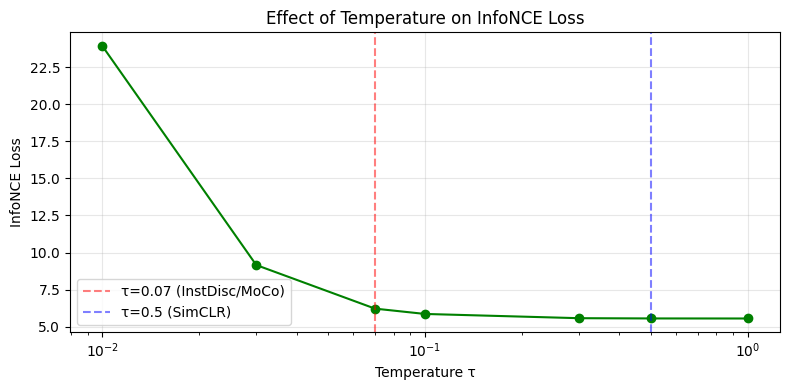

In [22]:
# ── 温度参数敏感性分析 ──
temperatures = [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 1.0]
q_demo = F.normalize(torch.randn(32, 128), dim=1)
p_demo = F.normalize(torch.randn(32, 128), dim=1)
n_demo = F.normalize(torch.randn(256, 128), dim=1)

losses_by_temp = []
for t in temperatures:
    l = info_nce_loss(q_demo, p_demo, n_demo, temperature=t).item()
    losses_by_temp.append(l)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temperatures, losses_by_temp, 'g-o', markersize=6)
ax.set_xlabel('Temperature τ'); ax.set_ylabel('InfoNCE Loss')
ax.set_title('Effect of Temperature on InfoNCE Loss')
ax.set_xscale('log')
ax.axvline(x=0.07, color='r', linestyle='--', alpha=0.5, label='τ=0.07 (InstDisc/MoCo)')
ax.axvline(x=0.5, color='b', linestyle='--', alpha=0.5, label='τ=0.5 (SimCLR)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 总结

本 Notebook 完整实现了对比学习早期两种代表性方法，并提供了 CPC、CMC 的核心代码片段：

1. **InstDisc (Memory Bank)**：通过外部存储解耦字典大小与 batch size，使用 NCE 采样高效训练
2. **InvaSpread (Batch 内对比)**：端到端训练，简洁优雅，是 SimCLR 的直接前身
3. **CPC (序列预测)**：将对比学习拓展到序列数据，用上下文预测未来
4. **CMC (多视图对比)**：跨模态/视图对齐，启发了 CLIP 等后续工作

这四种方法共同奠定了对比学习的理论和实践基础，后续的 MoCo、SimCLR、BYOL 等工作都建立在这些核心思想之上。